# 📘 AppleStore_EDA.ipynb



## 📌 Step 1: Import Required Libraries


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:

# Optional settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")



### 📌 Step 2: Load Cleaned CSV


In [4]:
df = pd.read_csv(r"D:\sql_python_mastery\Python_Journey\01_Apple_Store_Analytics_Project\cleaned_apple_store_data.csv")




#### 📌 Step 3: Revenue Column (if not already saved)


In [5]:
if 'revenue' not in df.columns:
    df['revenue'] = df['quantity'] * df['price']



#### 📌 Step 4: Total Revenue by Category


In [6]:
total_revenue_by_category = (
    df.groupby('category_name')['revenue']
    .sum()
    .reset_index()
    .sort_values(by='revenue', ascending=False)
)
print("\n💰 Total Revenue by Product Category:")
print(total_revenue_by_category)



💰 Total Revenue by Product Category:
  category_name   revenue
1       Laptops  295214.0
2   Smartphones  181168.0
3       Tablets  157986.0
0   Accessories  122990.0



#### 📌 Step 5: Store with Highest Number of Sales


In [7]:
store_sales = df.groupby('store_name')['quantity'].sum().reset_index()
store_sales = store_sales.sort_values(by='quantity', ascending=False)
top_store = store_sales.iloc[0]
print("\n🏬 Highest Sales Store:")
print(f"{top_store['store_name']} → {top_store['quantity']} units sold")



🏬 Highest Sales Store:
Apple Store San Antonio → 14 units sold



#### 📌 Step 6: Average Sale Value per Store


In [8]:
avg_sales = df.groupby('store_name')['revenue'].mean().reset_index()
avg_sales = avg_sales.sort_values(by='revenue', ascending=False)
print("\n📊 Average Sale Value per Store:")
print(avg_sales.head())



📊 Average Sale Value per Store:
                  store_name  revenue
101  Apple Store Los Angeles  15326.5
1      Apple Store  Fairview   9497.5
45     Apple Store Cleveland   8395.0
57        Apple Store Durham   7794.0
113        Apple Store Miami   7794.0



#### 📌 Step 7: Top 5 Products by Quantity Sold


In [9]:
top_products = (
    df.groupby('product_name')['quantity']
    .sum()
    .reset_index()
    .sort_values(by='quantity', ascending=False)
)
print("\n📦 Top 5 Best-Selling Products:")
print(top_products.head())



📦 Top 5 Best-Selling Products:
          product_name  quantity
117     iPhone 13 Mini        29
84         iPad Aurora        19
40         Mac Mini M2        15
133      iPhone 8 Plus        14
127  iPhone 16 Pro Max        13


### 📊 Sales Analysis

In [10]:
#1. What is the total revenue generated across all stores?
total_revenue = df['revenue'].sum()
print(f"\n💵 Total Revenue Generated: ${total_revenue:,.2f}")



💵 Total Revenue Generated: $757,358.00


In [11]:
#2. Which product generated the highest revenue?
highest_revenue_product = df.groupby('product_name')['revenue'].sum().idxmax()
highest_revenue = df.groupby('product_name')['revenue'].sum().max() 
print(f"\n💰 Product with Highest Revenue: {highest_revenue_product} (${highest_revenue:,.2f})")



💰 Product with Highest Revenue: Mac Pro (2019) ($65,989.00)


In [12]:
#3. What is the total revenue by product category?
total_revenue_by_category = df.groupby('category_name')['revenue'].sum().reset_index()
total_revenue_by_category = total_revenue_by_category.sort_values(by='revenue', ascending=False)
print("\n📊 Total Revenue by Product Category:")
print(total_revenue_by_category.head()) 



📊 Total Revenue by Product Category:
  category_name   revenue
1       Laptops  295214.0
2   Smartphones  181168.0
3       Tablets  157986.0
0   Accessories  122990.0


In [13]:
#4. Which store has the highest number of sales?
store_sales = df.groupby('store_name')['quantity'].sum().reset_index()
store_sales = store_sales.sort_values(by='quantity', ascending=False)
top_store = store_sales.iloc[0]
print("\n🏬 Highest Sales Store:")
print(f"{top_store['store_name']} → {top_store['quantity']} units sold")



🏬 Highest Sales Store:
Apple Store San Antonio → 14 units sold


In [14]:
# 5. Which city has the highest total revenue?
city_revenue = df.groupby('city')['revenue'].sum().reset_index()
city_revenue = city_revenue.sort_values(by='revenue', ascending=False)
print("\n🌆 City with Highest Total Revenue:")
print(f"{city_revenue.iloc[0]['city']} → ${city_revenue.iloc[0]['revenue']:,.2f}")



🌆 City with Highest Total Revenue:
Los Angeles → $30,653.00


In [15]:
# 6. What is the average sale value per store?
avg_sales = df.groupby('store_name')['revenue'].mean().reset_index()
avg_sales = avg_sales.sort_values(by='revenue', ascending=False)
print("\n📊 Average Sale Value per Store:")
print(avg_sales.head())



📊 Average Sale Value per Store:
                  store_name  revenue
101  Apple Store Los Angeles  15326.5
1      Apple Store  Fairview   9497.5
45     Apple Store Cleveland   8395.0
57        Apple Store Durham   7794.0
113        Apple Store Miami   7794.0


### 📦 Product Performance

In [16]:
#1. What are the top 5 best-selling products by quantity?
top_products_by_quantity = (
    df.groupby('product_name')['quantity']
    .sum()
    .reset_index()
    .sort_values(by='quantity', ascending=False)
)
print("\n📦 Top 5 Best-Selling Products by Quantity:")
print(top_products_by_quantity.head())



📦 Top 5 Best-Selling Products by Quantity:
          product_name  quantity
117     iPhone 13 Mini        29
84         iPad Aurora        19
40         Mac Mini M2        15
133      iPhone 8 Plus        14
127  iPhone 16 Pro Max        13


In [17]:
# 2. What are the top 5 most returned/repaired products (from warranty/claim data)?
top_returned_products = (
    df[df['claim_id'].notnull()]
    .groupby('product_name')['quantity']
    .sum()
    .reset_index()
    .sort_values(by='quantity', ascending=False)
)
print("\n🔧 Top 5 Most Returned/Repair Products:")
print(top_returned_products.head())



🔧 Top 5 Most Returned/Repair Products:
          product_name  quantity
60      iPhone 13 Mini        19
48      iPad Moonlight        10
11  Apple Watch Hermès         9
44        iPad Explore         8
13    Apple Watch SE 3         8


In [18]:
# 3. What is the average price of products by category?
avg_price_by_category = (
    df.groupby('category_name')['price']
    .mean()
    .reset_index()
    .round(2)
    .sort_values(by='price', ascending=False)
)
print("\n💲 Average Price of Products by Category:")
print(avg_price_by_category.head())



💲 Average Price of Products by Category:
  category_name    price
1       Laptops  1609.94
2   Smartphones   881.40
3       Tablets   656.02
0   Accessories   523.23


In [19]:
# 4. Which product category has the most diverse price range?
price_range_by_category = (
    df.groupby('category_name')['price']
    .agg(['min', 'max'])
    .reset_index()
)
print("\n📊 Price Range by Product Category:")
print(price_range_by_category.head())



📊 Price Range by Product Category:
  category_name  min   max
0   Accessories   29  1349
1       Laptops  699  5999
2   Smartphones  429  1499
3       Tablets  329  1299


### 🏬 Store Insights

In [20]:
# 1. What is the number of stores per country?
stores_per_country = df['country'].value_counts().reset_index()
stores_per_country.columns = ['country', 'number_of_stores']
print("\n🌍 Number of Stores per Country:")
print(stores_per_country.head())



🌍 Number of Stores per Country:
         country  number_of_stores
0  United States               151
1            UAE                 7
2      Australia                 7
3      Singapore                 7
4         Canada                 5


In [21]:
# 2. Which country generates the most revenue?
country_revenue = df.groupby('country')['revenue'].sum().reset_index()
country_revenue = country_revenue.sort_values(by='revenue', ascending=False)
print("\n🌍 Country with Highest Revenue:")
print(f"{country_revenue.iloc[0]['country']} → ${country_revenue.iloc[0]['revenue']:,.2f}")



🌍 Country with Highest Revenue:
United States → $401,684.00


In [27]:
#3. What is the sales trend over time? (monthly/yearly)

import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("cleaned_apple_store_data.csv")


In [29]:
df = pd.read_csv("cleaned_apple_store_data.csv")

# Parse the sale_date column properly
df['sale_date'] = pd.to_datetime(df['sale_date'], dayfirst=True, errors='coerce')


In [30]:

# Convert sale_date to datetime
df['sale_date'] = pd.to_datetime(df['sale_date'])


In [31]:

# 🗓️ Create Year-Month column
df['year_month'] = df['sale_date'].dt.to_period('M')


In [33]:
print(df['sale_date'].head())  # First 5 dates
print(df['sale_date'].isna().sum())  # Check for invalid rows (should be 0 ideally)


0   2023-12-01
1   2023-12-20
2   2024-05-05
3   2023-12-15
4   2020-04-18
Name: sale_date, dtype: datetime64[ns]
1


In [ ]:

# 📈 Group by Year-Month and sum revenue
df['revenue'] = df['quantity'] * df['price']
monthly_sales = df.groupby('year_month')['revenue'].sum().reset_index()


C:\Users\Syed\AppData\Local\Temp\ipykernel_12804\2048725963.py:14: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Syed\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


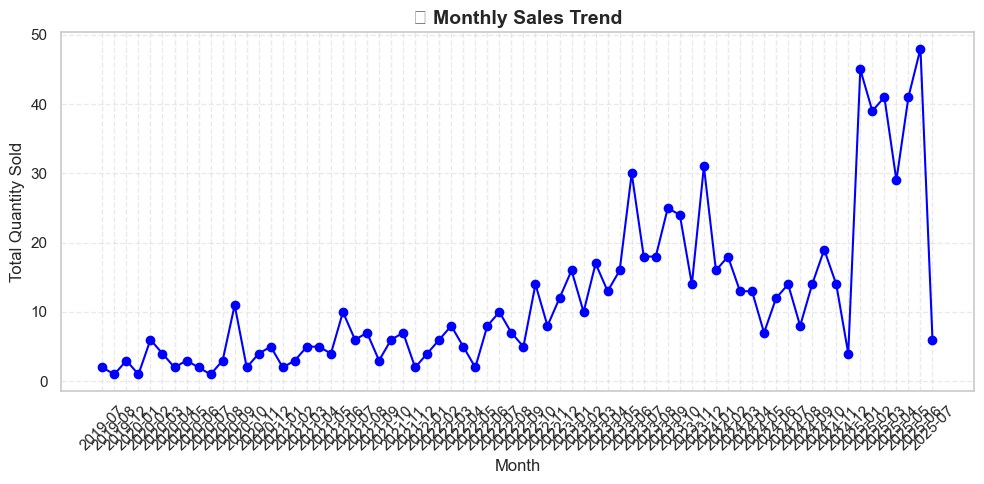

In [34]:

df['year_month'] = df['sale_date'].dt.to_period('M')
monthly_sales = df.groupby('year_month')['quantity'].sum().reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['year_month'], monthly_sales['quantity'], marker='o', color='blue')
plt.title("📊 Monthly Sales Trend", fontsize=14, weight='bold')
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [23]:
num_stores_ny = df[df['city'] == 'Dubai']['store_name'].nunique()
print(f"\n🏙️ Number of Stores in City Dubai: {num_stores_ny}")




🏙️ Number of Stores in City Dubai: 2


In [24]:
city = "Abu Dhabi"
num_stores = df[df['city'] == city]['store_name'].nunique()

print(f"\n🏙️ Number of Stores in City {city}: {num_stores}")




🏙️ Number of Stores in City Abu Dhabi: 2


#### Replace store name
df['store_name'] = df['store_name'].replace({
    'Apple Store Dubai': 'Apple Store Yas Mall'
})
##### Replace city for that store
df.loc[df['store_name'] == 'Apple Store Ridge Hill', 'city'] = 'New York'

df.loc[df['store_name'] == 'Apple Store Ridge Hill', 'city'] = 'New York'
df.loc[df['store_name'] == 'Apple Store Ridge Hill', ['store_name', 'city']] = ['Apple Store Ridge Hill', 'New York']


In [25]:
city = "New York"

# Filter stores in that city
stores_in_city = df[df['city'] == city]['store_name'].drop_duplicates()

# Count
num_stores = stores_in_city.nunique()

# Print
print(f"\n🏙️ Number of Stores in City {city}: {num_stores}")
print(f"🏬 Store(s) in {city}:")
for store in stores_in_city:
    print(f"• {store}")



🏙️ Number of Stores in City New York: 2
🏬 Store(s) in New York:
• Apple Store New York
• Apple Store Ridge Hill
